# JAX for numerical computing: from arrays to a PDE solver

JAX is often introduced through machine learning, but its core ideas are much broader: array programming, compilation for accelerators, automatic vectorization, and automatic differentiation. In this tutorial we use those ideas to solve and analyse a partial differential equation (PDE).

Our running example is the one-dimensional heat equation. The numerical method is deliberately simple so that the important part remains visible: **what must change when ordinary NumPy-style numerical code becomes transformable JAX code?**

> JAX can accelerate a numerical method; it does not make an inaccurate or unstable method correct. We will validate the discretization separately from measuring its speed.

## How to use this tutorial

**Audience.** Scientific Python users who are comfortable with NumPy arrays and basic calculus. No machine-learning experience is assumed.

**Prerequisites.** Required: array indexing, functions, and the idea of a finite difference. Helpful but optional: Fourier modes and explicit time integration.

**Time.** Allow about 60 minutes for the guided material and 20–40 minutes for the exercises. Run the notebook from top to bottom in a fresh kernel. Exercise solutions are included immediately after each exercise.

**Environment.** Use the `environment.yml` next to this notebook. Do not install packages from notebook cells: keeping setup outside the notebook makes the environment easier to reproduce and diagnose. The examples run on CPU or accelerator.

## Learning objectives

By the end, you should be able to:

1. write array code that is compatible with JAX transformations;
2. compile a pure numerical kernel and time it without measuring only dispatch or compilation;
3. express a time-stepping loop with `jax.lax` and validate it against an analytical solution;
4. vectorize a PDE solve over parameters with `jax.vmap`;
5. differentiate a scalar diagnostic through a numerical solver; and
6. identify when precision, stability, compilation cost, or problem size makes GPU execution a poor choice.

## 1. Setup: make precision and hardware explicit

NumPy normally creates 64-bit floating-point arrays. JAX defaults to 32-bit arithmetic because many accelerators favour it, and it disables 64-bit types unless explicitly configured. Here we enable 64-bit arithmetic because we will measure discretization error. This is a **numerical choice**, not a universally good default: consumer GPUs may execute 64-bit arithmetic much more slowly.

Configuration should happen before creating JAX arrays.

In [1]:
from time import perf_counter

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(f"JAX version: {jax.__version__}")
print(f"Default backend: {jax.default_backend()}")
print("Visible devices:")
for device in jax.devices():
    print(f"  {device}")

JAX version: 0.10.2


Default backend: gpu
Visible devices:
  cuda:0


A CPU result is valid: it means the same program is using a different backend. If you expected a GPU and do not see one, fix the environment before drawing performance conclusions. The [JAX installation guide](https://docs.jax.dev/en/latest/installation.html) is the authoritative source for current platform-specific packages.

## 2. The programming model in one example

`jax.numpy` deliberately resembles NumPy, but JAX arrays are immutable. Instead of changing an array element in place, use a functional update with `.at[...].set(...)`. The returned array is a new value; under compilation, JAX can often reuse storage when that is safe.

Immutability is not cosmetic. JAX traces functions to construct computations that can be compiled, vectorized, or differentiated. Hidden mutation and Python side effects make those transformations ambiguous.

In [2]:
values = jnp.linspace(0.0, 1.0, 5)
updated = values.at[2].set(99.0)

print("original:", values)
print("updated: ", updated)
print("dtype:   ", values.dtype)

original: [0.   0.25 0.5  0.75 1.  ]
updated:  [ 0.    0.25 99.    0.75  1.  ]
dtype:    float64


A useful working rule is: **functions to be transformed should receive all changing inputs as arguments and return their results explicitly**. Pure functions are easier to compile, test, and reason about even outside JAX.

## 3. Model problem: the periodic heat equation

We solve

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2},
\qquad 0 \le x < L,
$$

with periodic boundary conditions. Here $u(x,t)$ could represent temperature and $\alpha>0$ is the diffusivity. For the initial condition

$$u(x,0)=\sin(2\pi x/L),$$

the exact solution is

$$u(x,t)=\exp\left[-\alpha(2\pi/L)^2t\right]\sin(2\pi x/L).$$

This exact solution gives us a strong correctness check. Agreement with it tests the numerical implementation; successful compilation alone does not.

### Spatial and temporal discretization

On a uniform periodic grid, the centred second difference is

$$
(D_{xx}u)_i = \frac{u_{i-1}-2u_i+u_{i+1}}{\Delta x^2}.
$$

A forward Euler step is

$$u^{n+1}=u^n+\alpha\Delta t D_{xx}u^n.$$

For this one-dimensional scheme, stability requires

$$r=\frac{\alpha\Delta t}{\Delta x^2}\le\frac{1}{2}.$$

The dimensionless quantity $r$ is commonly called the **diffusion number** or **Fourier number**. It compares the time step with the diffusive time scale $\Delta x^2/\alpha$, so refining the grid requires $\Delta t=O(\Delta x^2)$. This is not the same quantity as the Courant number $\lambda=c\Delta t/\Delta x$ used for the wave equation, where $\Delta t=O(\Delta x)$. The different symbols help keep those two meanings distinct.

Notice that this restriction comes from the algorithm, not from JAX or the GPU.

In [3]:
def laplacian_periodic(u, dx):
    """Second-order centred Laplacian on a one-dimensional periodic grid."""
    return (jnp.roll(u, 1) - 2.0 * u + jnp.roll(u, -1)) / dx**2


def euler_step(u, alpha, dt, dx):
    """Advance the heat equation by one explicit Euler step."""
    return u + alpha * dt * laplacian_periodic(u, dx)


def solve_heat(u0, alpha, dt, dx, n_steps):
    """Advance a state without a Python-side loop."""
    def body(_, u):
        return euler_step(u, alpha, dt, dx)

    return jax.lax.fori_loop(0, n_steps, body, u0)


def exact_heat_mode(x, t, alpha, length=1.0, mode=1):
    """Exact heat-equation solution for sin(2*pi*mode*x/length)."""
    wave_number = 2.0 * jnp.pi * mode / length
    return jnp.exp(-alpha * wave_number**2 * t) * jnp.sin(wave_number * x)

`jnp.roll` encodes the periodic neighbours without boundary branches. `jax.lax.fori_loop` keeps the time loop inside the staged computation. A Python loop can be acceptable while exploring, but a long Python loop is expensive to trace when enclosed by `jit` and repeatedly dispatches work when left outside it.

In [4]:
length = 1.0
n_points = 256
alpha = 0.01
final_time = 0.1
target_diffusion_number = 0.4

dx = length / n_points
x = jnp.arange(n_points, dtype=jnp.float64) * dx
u0 = exact_heat_mode(x, t=0.0, alpha=alpha, length=length)

dt_limit = 0.5 * dx**2 / alpha
suggested_dt = target_diffusion_number * dx**2 / alpha
n_steps = int(np.ceil(final_time / suggested_dt))
dt = final_time / n_steps
diffusion_number = alpha * dt / dx**2

print(f"grid points: {n_points}")
print(f"time steps:  {n_steps}")
print(f"dt limit:    {dt_limit:.3e}")
print(f"chosen dt:   {dt:.3e}")
print(f"diffusion number r = alpha*dt/dx^2: {diffusion_number:.3f}")
assert diffusion_number <= 0.5

grid points: 256
time steps:  164
dt limit:    7.629e-04
chosen dt:   6.098e-04
diffusion number r = alpha*dt/dx^2: 0.400


## 4. Compile the whole solve

`jax.jit` traces a function for particular input shapes, dtypes, and static arguments, then hands the computation to the backend compiler. The loop count controls the staged program and is marked static here. Changing it can therefore trigger recompilation.

The first call includes compilation. Later calls with compatible arguments reuse the compiled executable.

In [5]:
solve_heat_jit = jax.jit(solve_heat, static_argnames=("n_steps",))

u_final = solve_heat_jit(u0, alpha, dt, dx, n_steps)
u_final.block_until_ready()
u_exact = exact_heat_mode(x, final_time, alpha, length)

relative_l2_error = float(
    jnp.linalg.norm(u_final - u_exact) / jnp.linalg.norm(u_exact)
)
print(f"relative L2 error: {relative_l2_error:.3e}")

relative L2 error: 2.770e-06


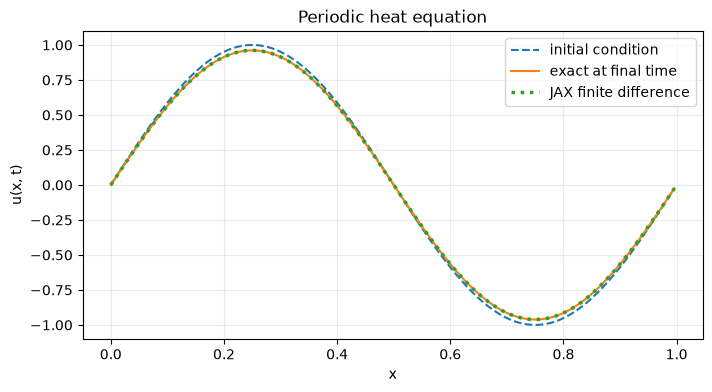

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.asarray(x), np.asarray(u0), "--", label="initial condition")
ax.plot(np.asarray(x), np.asarray(u_exact), label="exact at final time")
ax.plot(np.asarray(x), np.asarray(u_final), ":", linewidth=2.5, label="JAX finite difference")
ax.set(xlabel="x", ylabel="u(x, t)", title="Periodic heat equation")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

The curves should nearly overlap, but a plot is a weak test: visually similar answers can still have the wrong convergence behaviour. We therefore refine the grid. Because $\Delta t$ is chosen proportional to $\Delta x^2$, both the first-order time error and the second-order spatial error are expected to scale as $O(\Delta x^2)$ in this experiment.

In [7]:
def run_refinement(n, alpha=0.01, final_time=0.1, length=1.0):
    dx_n = length / n
    x_n = jnp.arange(n, dtype=jnp.float64) * dx_n
    u0_n = exact_heat_mode(x_n, 0.0, alpha, length)

    target_dt = 0.4 * dx_n**2 / alpha
    steps_n = int(np.ceil(final_time / target_dt))
    dt_n = final_time / steps_n

    numerical = solve_heat_jit(u0_n, alpha, dt_n, dx_n, steps_n)
    exact = exact_heat_mode(x_n, final_time, alpha, length)
    error = jnp.linalg.norm(numerical - exact) / jnp.linalg.norm(exact)
    return dx_n, float(error)


grid_sizes = np.array([64, 128, 256, 512])
refinement_results = [run_refinement(int(n)) for n in grid_sizes]
grid_spacings = np.array([result[0] for result in refinement_results])
errors = np.array([result[1] for result in refinement_results])
observed_order = np.polyfit(np.log(grid_spacings), np.log(errors), 1)[0]

for n, error in zip(grid_sizes, errors):
    print(f"N={n:4d}: relative L2 error = {error:.3e}")
print(f"observed convergence order: {observed_order:.2f}")

N=  64: relative L2 error = 3.920e-05
N= 128: relative L2 error = 1.108e-05
N= 256: relative L2 error = 2.770e-06
N= 512: relative L2 error = 6.925e-07
observed convergence order: 1.95


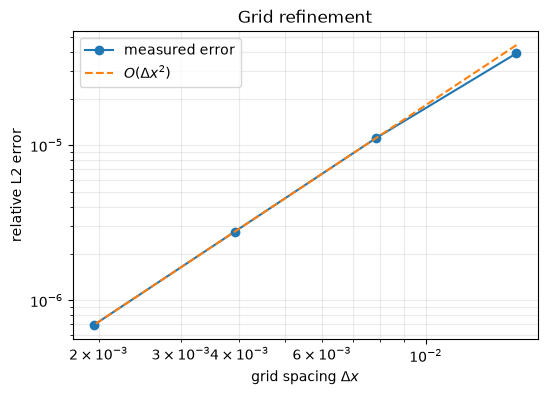

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(grid_spacings, errors, "o-", label="measured error")
reference = errors[-1] * (grid_spacings / grid_spacings[-1]) ** 2
ax.loglog(grid_spacings, reference, "--", label=r"$O(\Delta x^2)$")
ax.set(xlabel=r"grid spacing $\Delta x$", ylabel="relative L2 error", title="Grid refinement")
ax.legend()
ax.grid(which="both", alpha=0.25)
plt.show()

### Exercise 1 — diagnose instability (10 minutes)

The code below starts with the highest-frequency pattern representable on an even grid. Before running the solution, predict what one Euler step does when $r=0.55$. Will the amplitude decay, remain constant, or grow? Explain the result using the amplification factor of the discrete Laplacian.

**Success criterion:** identify that the failure is a time-integration stability problem, not a JAX or floating-point bug.

<details>
<summary><strong>Reasoning and solution</strong></summary>

For the alternating mode, the centred discrete Laplacian has eigenvalue $-4/\Delta x^2$. Forward Euler therefore multiplies the mode by $1-4r$. At $r=0.55$, the factor is $-1.2$: its sign flips and its magnitude grows by 20% every step.

Run the next cell to verify the prediction.
</details>

In [9]:
unstable_r = 0.55
unstable_dt = unstable_r * dx**2 / alpha
alternating_mode = jnp.where(jnp.arange(n_points) % 2 == 0, 1.0, -1.0)
after_one_step = euler_step(alternating_mode, alpha, unstable_dt, dx)
after_twenty_steps = solve_heat_jit(
    alternating_mode, alpha, unstable_dt, dx, n_steps=20
)

one_step_factor = float(after_one_step[0] / alternating_mode[0])
growth = float(jnp.max(jnp.abs(after_twenty_steps)))
print(f"measured one-step factor: {one_step_factor:.2f}")
print(f"maximum amplitude after 20 steps: {growth:.2f}")

measured one-step factor: -1.20
maximum amplitude after 20 steps: 38.34


## 5. Time JAX honestly

Two effects make naive timings misleading:

- the first call includes tracing and compilation;
- accelerator dispatch is asynchronous, so Python can return before the computation finishes.

Use `.block_until_ready()` to measure completion without copying the full result back to the host. Compare first-call latency with a warmed call; they answer different questions.

In [10]:
benchmark_points = 16_384
benchmark_x = jnp.arange(benchmark_points, dtype=jnp.float64) / benchmark_points
benchmark_u0 = jnp.sin(2.0 * jnp.pi * benchmark_x)
benchmark_dx = 1.0 / benchmark_points
benchmark_dt = 0.4 * benchmark_dx**2 / alpha
benchmark_steps = 200

start = perf_counter()
solve_heat_jit(
    benchmark_u0, alpha, benchmark_dt, benchmark_dx, benchmark_steps
).block_until_ready()
first_call = perf_counter() - start

start = perf_counter()
solve_heat_jit(
    benchmark_u0, alpha, benchmark_dt, benchmark_dx, benchmark_steps
).block_until_ready()
warmed_call = perf_counter() - start

print(f"first call (compile + execute): {first_call:.4f} s")
print(f"warmed execution:              {warmed_call:.4f} s")

first call (compile + execute): 0.0877 s
warmed execution:              0.0075 s


Do not interpret this as a CPU-versus-GPU benchmark. A fair comparison would use equivalent algorithms and dtypes, warm both implementations appropriately, include or exclude transfer costs according to the application, and report repeated measurements. Small grids often favour the CPU because compilation and launch overhead dominate.

## 6. Vectorize a parameter ensemble with `vmap`

Many scientific workloads solve the same discretized problem for several parameter values. `jax.vmap` adds a mapped array axis without writing an explicit batch loop. We choose one time step that is stable for the largest diffusivity, so every ensemble member takes the same number of steps.

This is a convenience and often a performance opportunity, but it increases memory use because all states coexist. For a very large ensemble, batching or distributing the work may be necessary.

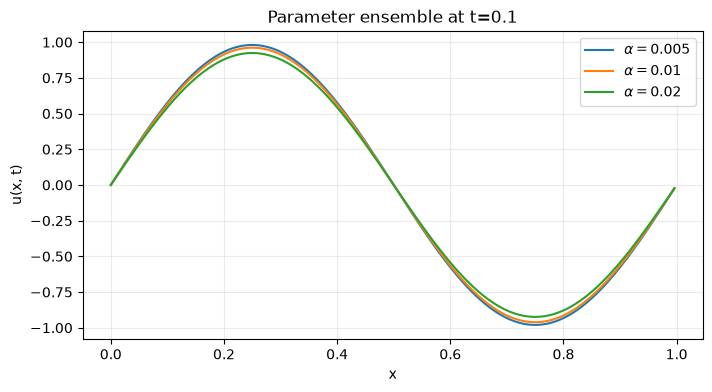

In [11]:
diffusivities = jnp.array([0.005, 0.01, 0.02])
ensemble_dt_target = 0.4 * dx**2 / float(jnp.max(diffusivities))
ensemble_steps = int(np.ceil(final_time / ensemble_dt_target))
ensemble_dt = final_time / ensemble_steps

def solve_one_parameter(diffusivity):
    return solve_heat(u0, diffusivity, ensemble_dt, dx, ensemble_steps)


solve_ensemble = jax.jit(jax.vmap(solve_one_parameter))
ensemble_solutions = solve_ensemble(diffusivities)
ensemble_solutions.block_until_ready()

fig, ax = plt.subplots(figsize=(8, 4))
for a, solution in zip(np.asarray(diffusivities), np.asarray(ensemble_solutions)):
    ax.plot(np.asarray(x), solution, label=fr"$\alpha={a:g}$")
ax.set(xlabel="x", ylabel="u(x, t)", title=f"Parameter ensemble at t={final_time}")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

Interpret the result physically: larger diffusivity damps the mode more quickly. `vmap` changes how the solves are scheduled; it does not change that model prediction.

## 7. Differentiate through the solver

Automatic differentiation is useful outside machine learning. Examples include sensitivity analysis, parameter estimation, design optimization, and adjoint-like calculations. Here an analytical final state acts as a small synthetic observation, and we differentiate the mean-squared mismatch with respect to $\alpha$.

The derivative is for the **implemented discrete solver** (discretize, then differentiate), not automatically for the continuous PDE. Its scientific usefulness still depends on convergence, conditioning, and smoothness. Iterative stopping rules, limiters, discontinuities, and chaotic dynamics can all make gradients misleading or fragile.

In [12]:
true_alpha = 0.013
observed_final_state = exact_heat_mode(x, final_time, true_alpha, length)

def mismatch(candidate_alpha):
    predicted = solve_heat(
        u0, candidate_alpha, ensemble_dt, dx, ensemble_steps
    )
    return jnp.mean((predicted - observed_final_state) ** 2)


mismatch_and_gradient = jax.jit(jax.value_and_grad(mismatch))
trial_alpha = jnp.array(0.008)
loss, gradient = mismatch_and_gradient(trial_alpha)

print(f"trial alpha: {float(trial_alpha):.4f}")
print(f"mismatch:    {float(loss):.3e}")
print(f"d(mismatch)/d(alpha): {float(gradient):.3e}")
print("The negative gradient points toward the larger true diffusivity.")

trial alpha: 0.0080
mismatch:    1.793e-04
d(mismatch)/d(alpha): -7.244e-02
The negative gradient points toward the larger true diffusivity.


### Exercise 2 — transfer to a new initial condition (15–20 minutes)

Consider

$$u(x,0)=\sin(2\pi x/L)+\tfrac{1}{2}\sin(8\pi x/L).$$

1. Predict which component will decay faster and by what relative mechanism.
2. Reuse the existing solver without changing `euler_step`.
3. Estimate each mode's amplitude before and after the solve. Do the measurements support your prediction?

**Hint.** On this grid, twice the mean of `u * sin(k*x)` estimates the sine coefficient.

**Success criterion:** connect the $k^2$ decay rate to the numerical result and explain why no solver rewrite was needed.

<details>
<summary><strong>Reasoning</strong></summary>

A Fourier mode with wave number $k$ decays as $\exp(-\alpha k^2t)$. The second component has four times the wave number and therefore sixteen times the decay rate. The PDE solver operates on an arbitrary grid state, so only the initial condition changes.
</details>

In [13]:
mode_1 = jnp.sin(2.0 * jnp.pi * x / length)
mode_4 = jnp.sin(8.0 * jnp.pi * x / length)
two_mode_initial = mode_1 + 0.5 * mode_4
two_mode_final = solve_heat_jit(
    two_mode_initial, alpha, dt, dx, n_steps
)

def sine_coefficient(state, basis):
    return 2.0 * jnp.mean(state * basis)


initial_coefficients = jnp.array([
    sine_coefficient(two_mode_initial, mode_1),
    sine_coefficient(two_mode_initial, mode_4),
])
final_coefficients = jnp.array([
    sine_coefficient(two_mode_final, mode_1),
    sine_coefficient(two_mode_final, mode_4),
])
decay_factors = final_coefficients / initial_coefficients

print("initial coefficients:", initial_coefficients)
print("final coefficients:  ", final_coefficients)
print("measured decay factors:", decay_factors)

initial coefficients: [1.  0.5]
final coefficients:   [0.96128804 0.26566683]
measured decay factors: [0.96128804 0.53133365]


## 8. What this example does—and does not—show

### Advantages

- A NumPy-like array interface can target CPU, GPU, and other backends.
- `jit`, `vmap`, and automatic differentiation compose around the same pure functions.
- Whole-program compilation can fuse array operations and keep loops on the device.
- Explicit data flow tends to improve testability and reproducibility.

### Costs and failure modes

- Compilation latency can dominate short runs or frequently changing shapes.
- GPU launch and transfer overhead can make small problems slower than NumPy on a CPU.
- Functional style, static shapes, and staged control flow require redesign of mutation-heavy code.
- Accelerator memory is finite; vectorizing an ensemble can multiply the live state size.
- Precision differs from traditional NumPy defaults, and 64-bit throughput varies sharply by device.
- JAX transformations validate neither the PDE model nor the discretization. Conservation, stability, convergence, and boundary conditions still need scientific tests.

For a production PDE code, also investigate sparse or matrix-free operators, implicit solvers, preconditioning, boundary-condition abstractions, checkpointing for reverse-mode differentiation, multi-device decomposition, and comparison with mature domain-specific solvers.

## 9. Final reproducibility checks

These are deliberately lightweight smoke tests, not a proof of correctness. They catch a broken execution order, loss of the expected convergence trend, an unstable configured solve, or failure of automatic differentiation.

In [14]:
assert relative_l2_error < 1.0e-3
assert 1.8 < observed_order < 2.2
assert diffusion_number <= 0.5
assert np.isfinite(float(loss))
assert np.isfinite(float(gradient))
assert float(gradient) < 0.0
print("All tutorial smoke checks passed.")

All tutorial smoke checks passed.


## Summary and next steps

The durable ideas are larger than the API calls:

1. express numerical kernels as explicit transformations of arrays;
2. separate compilation cost, execution cost, and data movement when reasoning about performance;
3. validate numerical stability and convergence independently of backend execution;
4. use vectorization when independent computations share structure, while watching memory use; and
5. interpret automatic derivatives as derivatives of the discretized program.

Possible extensions are a two-dimensional stencil, Dirichlet or Neumann boundary conditions, an implicit method, comparison with NumPy, and a parameter-estimation exercise with noisy observations.

## References

- [JAX quickstart: how to think in JAX](https://docs.jax.dev/en/latest/quickstart.html)
- [JAX installation](https://docs.jax.dev/en/latest/installation.html)
- [Default dtypes and the X64 flag](https://docs.jax.dev/en/latest/default_dtypes.html)
- [Benchmarking JAX code](https://docs.jax.dev/en/latest/benchmarking.html)
- [JAX control flow operators](https://docs.jax.dev/en/latest/control-flow.html)